In [1]:
# Final Assignement Part 1
## Automobile Data Visualization
### By Ruel Laranjo




Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='str')
Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='str')


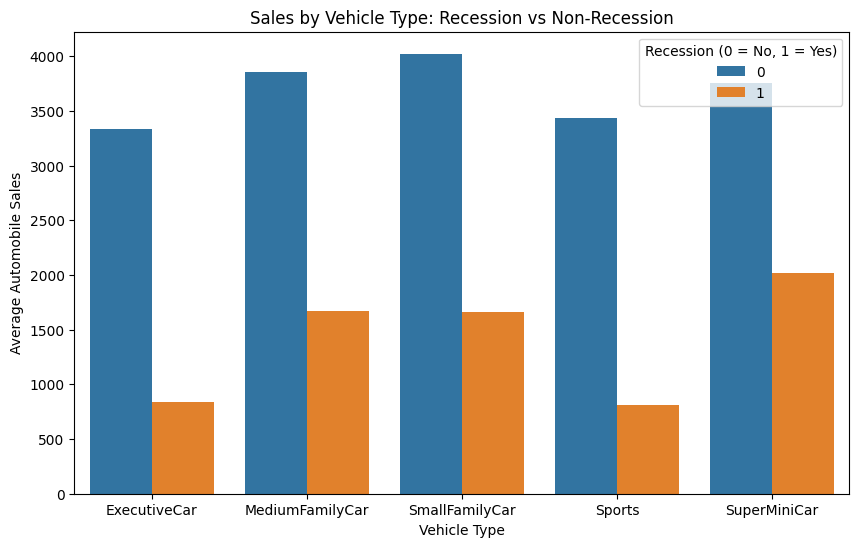

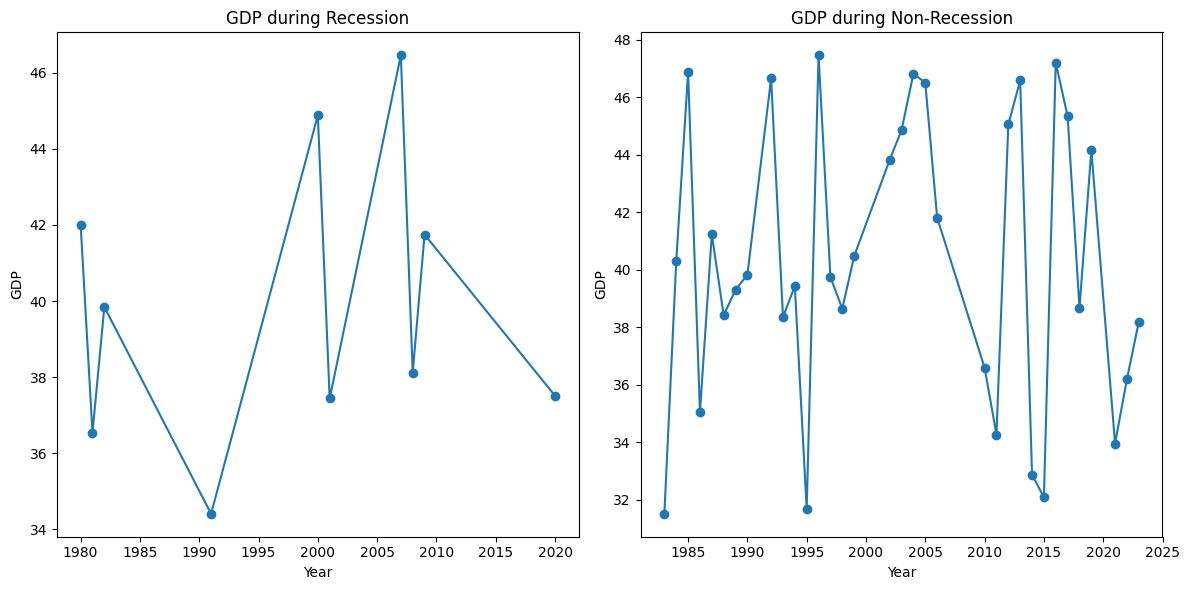

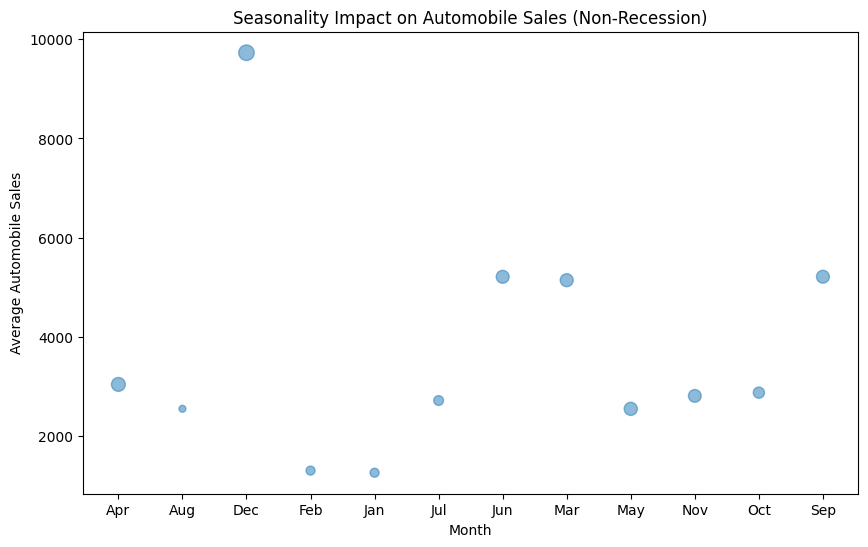

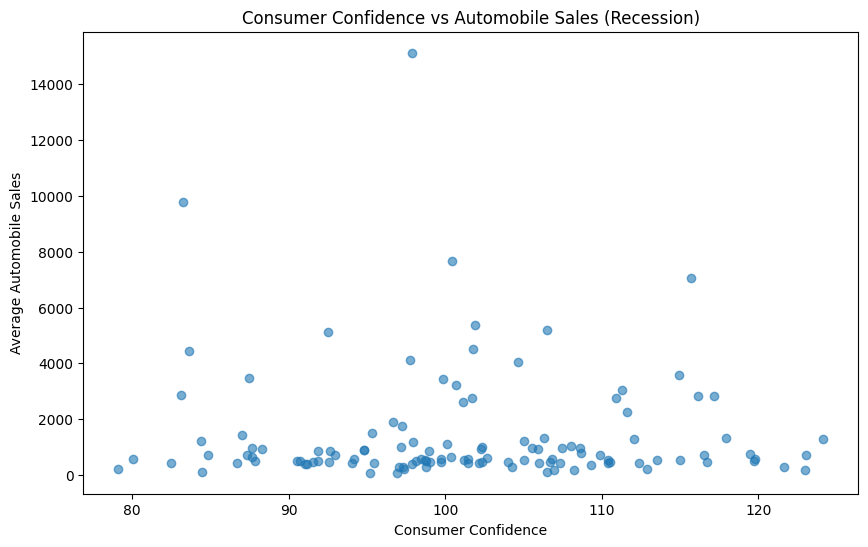

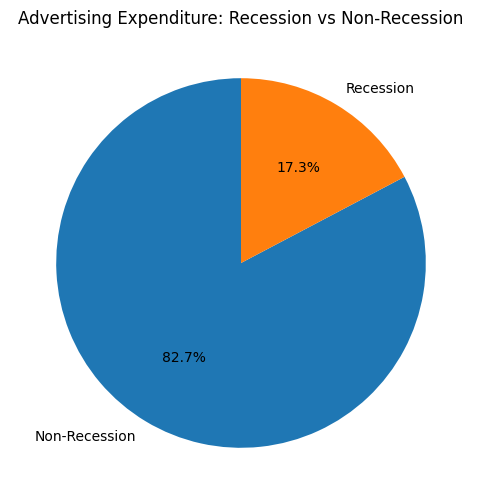

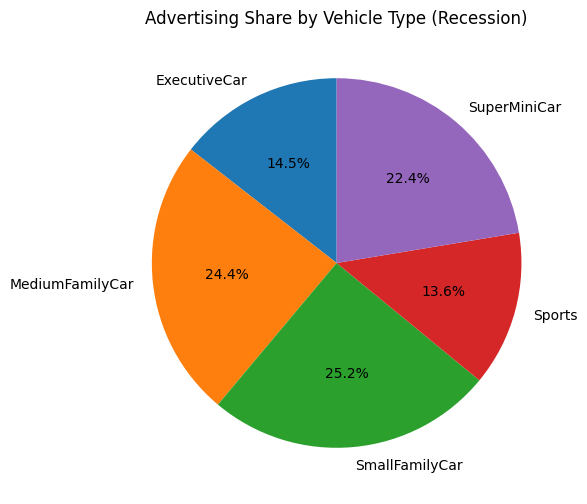

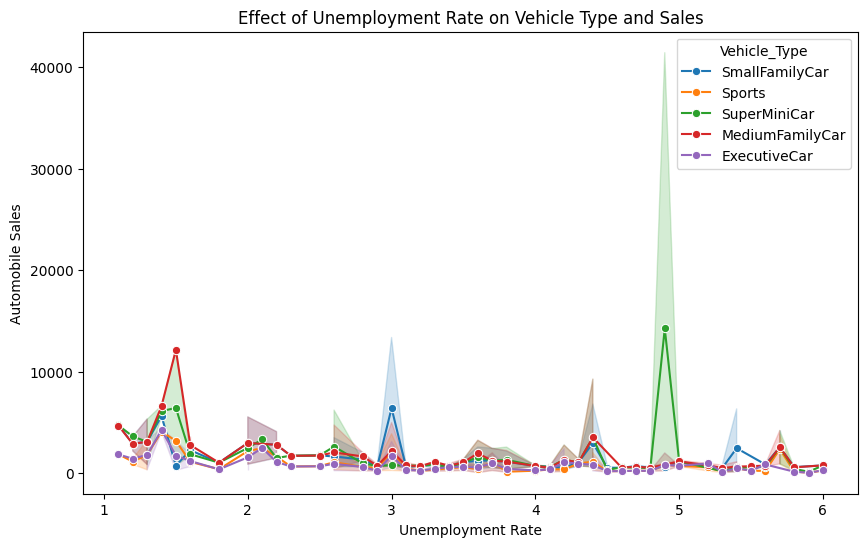

         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicle_Type      City  
0                5.4    

NameError: name 'folium' is not defined

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import dcc, html
import seaborn as sns

# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

df = pd.read_csv(url)


# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Prepare data
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

# Create Plotly figure
fig = px.line(
    df_line,
    x='Year',
    y='Automobile_Sales',
    title='Average Automobile Sales by Year'
)

# Initialize Dash app
app = dash.Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1("Automobile Sales Dashboard", style={'textAlign': 'center'}),
    dcc.Graph(figure=fig)
])

print(df.columns)

# Prepare data
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

# Create Plotly figure
fig = px.line(
    df_line,
    x='Year',
    y='Automobile_Sales',
    title='Average Automobile Sales by Year'
)

# Initialize Dash app
app = dash.Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1("Automobile Sales Dashboard", style={'textAlign': 'center'}),
    dcc.Graph(figure=fig)
])

print(df.columns)

# Prepare data
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

# Create Plotly figure
fig = px.line(
    df_line,
    x='Year',
    y='Automobile_Sales',
    title='Average Automobile Sales by Year'
)

# Initialize Dash app 
app = dash.Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1("Automobile Sales Dashboard", style={'textAlign': 'center'}),
    dcc.Graph(figure=fig)
])

# Group data
df_bar = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_bar,
    x='Vehicle_Type',
    y='Automobile_Sales',
    hue='Recession'
)

plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.title('Sales by Vehicle Type: Recession vs Non-Recession')
plt.legend(title='Recession (0 = No, 1 = Yes)')

plt.show()

# Filter data
rec_data = df[df['Recession'] == 1]
nonrec_data = df[df['Recession'] == 0]

# Group by Year 
rec_group = rec_data.groupby('Year')['GDP'].mean().reset_index()
nonrec_group = nonrec_data.groupby('Year')['GDP'].mean().reset_index()

# Create figure
fig = plt.figure(figsize=(12,6))

# Subplot 1: Recession
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(rec_group['Year'], rec_group['GDP'], marker='o')
ax1.set_title('GDP during Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')

# Subplot 2: Non-Recession
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(nonrec_group['Year'], nonrec_group['GDP'], marker='o')
ax2.set_title('GDP during Non-Recession')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP')

plt.tight_layout()
plt.show()

# Filter only NON-recession data
nonrec_data = df[df['Recession'] == 0]

# Group by Month 
month_data = nonrec_data.groupby('Month').agg({
    'Automobile_Sales': 'mean',
    'Seasonality_Weight': 'mean'
}).reset_index()

# Sort months
month_data = month_data.sort_values(by='Month')

# Create bubble plot
plt.figure(figsize=(10,6))

plt.scatter(
    month_data['Month'],
    month_data['Automobile_Sales'],
    s=month_data['Seasonality_Weight'] * 100,
    alpha=0.5
)

# Labels and title
plt.title('Seasonality Impact on Automobile Sales (Non-Recession)')
plt.xlabel('Month')
plt.ylabel('Average Automobile Sales')

plt.show()


# Filter recession data
rec_data = df[df['Recession'] == 1]

# OPTIONAL: Group to smooth data
rec_group = rec_data.groupby('Consumer_Confidence')['Automobile_Sales'].mean().reset_index()

# Create scatter plot
plt.figure(figsize=(10,6))

plt.scatter(
    rec_group['Consumer_Confidence'],
    rec_group['Automobile_Sales'],
    alpha=0.6
)

# Labels and title
plt.title('Consumer Confidence vs Automobile Sales (Recession)')
plt.xlabel('Consumer Confidence')
plt.ylabel('Average Automobile Sales')

plt.show()

# -------- PIE CHART 1 --------
ad_exp = df.groupby('Recession')['Advertising_Expenditure'].sum()

# Ensure correct label order
labels = ['Non-Recession', 'Recession']

plt.figure(figsize=(6,6))
plt.pie(ad_exp.values, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure: Recession vs Non-Recession')
plt.show()

# -------- PIE CHART 2 --------
# Filter recession data
rec_data = df[df['Recession'] == 1]

# Group by Vehicle_Type
ad_exp_type = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8,6))
plt.pie(ad_exp_type.values, labels=ad_exp_type.index, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Share by Vehicle Type (Recession)')
plt.show()


# Filter recession data
rec_data = df[df['Recession'] == 1]

# Create line plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rec_data,
    x='unemployment_rate',   
    y='Automobile_Sales',
    hue='Vehicle_Type',
    marker='o'
)

# Titles and labels
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')

plt.show()

# Load dataset

# Check if data loaded
print(df.head())

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_')


# Filter recession data
rec_data = df[df['Recession'] == 1]

# Group by State
sales_by_state = rec_data.groupby('City')['Automobile_Sales'].sum().reset_index()

# Print grouped data (THIS is what your task wants)
print(sales_by_state)

# Create map
map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Add Choropleth
folium.Choropleth(
    geo_data='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json',
    data=sales_by_state,
    columns=['State', 'Automobile_Sales'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Automobile Sales during Recession'
).add_to(map1)

Choropleth(
    geo_data='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json',
    
)

# Save map
map1.save("recession_map.html")

print("Map created successfully! Open recession_map.html")

print("Map has been successfully created and saved as 'recession_map.html'")

print(df.columns.tolist())

In [ ]:
# Run app
if __name__ == "__main__":
    app.run(debug=True)